In [1]:
pip install nba_api

Note: you may need to restart the kernel to use updated packages.


In [30]:
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd

# Récupérer les matchs d'une équipe spécifique ou de la ligue entière
gamefinder = leaguegamefinder.LeagueGameFinder(league_id_nullable='00')  # NBA league ID = '00'
games = gamefinder.get_data_frames()[0]

# Afficher les 5 premiers résultats
print(games.head())

# Enregistrer dans un fichier CSV pour usage ultérieur
games.to_csv('nba_games.csv', index=False)

  SEASON_ID     TEAM_ID TEAM_ABBREVIATION               TEAM_NAME     GAME_ID  \
0     22024  1610612761               TOR         Toronto Raptors  0022400359   
1     22024  1610612752               NYK         New York Knicks  0022400359   
2     22024  1610612750               MIN  Minnesota Timberwolves  0022400355   
3     22024  1610612737               ATL           Atlanta Hawks  0022400350   
4     22024  1610612747               LAL      Los Angeles Lakers  0022400358   

    GAME_DATE      MATCHUP WL  MIN  PTS  ...  FT_PCT  OREB  DREB  REB  AST  \
0  2024-12-09  TOR vs. NYK  L  240  108  ...   0.818    17    34   51   23   
1  2024-12-09    NYK @ TOR  W  240  113  ...   0.632     6    34   40   32   
2  2024-12-08    MIN @ GSW  L  241  106  ...   0.750     7    32   39   22   
3  2024-12-08  ATL vs. DEN  L  239  111  ...   0.741    19    26   45   26   
4  2024-12-08  LAL vs. POR  W  241  107  ...   0.857     8    32   40   25   

   STL  BLK  TOV  PF  PLUS_MINUS  
0    4   

In [31]:
import pandas as pd

# Charger les données NBA extraites (par exemple, depuis un fichier CSV)
file_path = 'nba_games.csv'  # Remplace par le chemin vers ton fichier
data = pd.read_csv(file_path)

# Analyse de base du jeu de données
def analyze_dataset(df):
    print("### Aperçu des 5 premières lignes ###")
    print(df.head(), "\n")
    
    print("### Informations sur les colonnes ###")
    print(df.info(), "\n")
    
    print("### Liste des colonnes ###")
    print(df.columns.tolist(), "\n")
    
    print("### Statistiques descriptives ###")
    print(df.describe(include='all'), "\n")
    
    print("### Recherche des valeurs manquantes ###")
    print(df.isnull().sum(), "\n")
    
    print("### Aperçu des valeurs uniques par colonne ###")
    for column in df.columns:
        print(f"{column}: {df[column].nunique()} valeurs uniques")
        print(df[column].unique()[:10], "\n")  # Affiche les 10 premières valeurs uniques pour chaque colonne

# Exécuter l'analyse
analyze_dataset(data)

### Aperçu des 5 premières lignes ###
   SEASON_ID     TEAM_ID TEAM_ABBREVIATION               TEAM_NAME   GAME_ID  \
0      22024  1610612761               TOR         Toronto Raptors  22400359   
1      22024  1610612752               NYK         New York Knicks  22400359   
2      22024  1610612750               MIN  Minnesota Timberwolves  22400355   
3      22024  1610612737               ATL           Atlanta Hawks  22400350   
4      22024  1610612747               LAL      Los Angeles Lakers  22400358   

    GAME_DATE      MATCHUP WL  MIN  PTS  ...  FT_PCT  OREB  DREB  REB  AST  \
0  2024-12-09  TOR vs. NYK  L  240  108  ...   0.818    17    34   51   23   
1  2024-12-09    NYK @ TOR  W  240  113  ...   0.632     6    34   40   32   
2  2024-12-08    MIN @ GSW  L  241  106  ...   0.750     7    32   39   22   
3  2024-12-08  ATL vs. DEN  L  239  111  ...   0.741    19    26   45   26   
4  2024-12-08  LAL vs. POR  W  241  107  ...   0.857     8    32   40   25   

   STL  BLK 

In [32]:
missing_data_rows = data.isnull().any(axis=1).sum()
print(f"Nombre de lignes avec des données manquantes : {missing_data_rows}")

Nombre de lignes avec des données manquantes : 7


In [33]:
# Supprimer les lignes avec des valeurs manquantes
df_cleaned = data.dropna()

# Vérification du nombre de lignes restantes
print(f"Nombre de lignes après suppression : {df_cleaned.shape[0]}")


Nombre de lignes après suppression : 29993


In [34]:
# Création d'une colonne de résultat binaire (1 = victoire, 0 = défaite)
df_cleaned['WIN'] = df_cleaned['WL'].apply(lambda x: 1 if x == 'W' else 0)

# Encodage des équipes en variables numériques
df_cleaned['TEAM_ABBREVIATION'] = df_cleaned['TEAM_ABBREVIATION'].astype('category').cat.codes

# Vérification des colonnes importantes
print(df_cleaned[['GAME_ID', 'TEAM_ABBREVIATION', 'PTS', 'WIN']].head())

    GAME_ID  TEAM_ABBREVIATION  PTS  WIN
0  22400359                 73  108    0
1  22400359                 52  113    1
2  22400355                 46  106    0
3  22400350                  2  111    0
4  22400358                 39  107    1


/var/folders/49/ck8bc0m57zgd8z_xp3lj_w340000gn/T/ipykernel_82798/2171559163.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['WIN'] = df_cleaned['WL'].apply(lambda x: 1 if x == 'W' else 0)
/var/folders/49/ck8bc0m57zgd8z_xp3lj_w340000gn/T/ipykernel_82798/2171559163.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['TEAM_ABBREVIATION'] = df_cleaned['TEAM_ABBREVIATION'].astype('category').cat.codes


In [65]:
# Créer une copie explicite du DataFrame
df_cleaned = df_cleaned.copy()

# Maintenant, vous pouvez effectuer les opérations sans avertissements
df_cleaned.loc[:, 'LOCATION'] = df_cleaned['MATCHUP'].apply(lambda x: 'extérieur' if '@' in x else 'domicile')
df_cleaned.loc[:, 'LOCATION'] = (df_cleaned['LOCATION'] == 'domicile').astype(int)

# Vérification du résultat
df_cleaned[['MATCHUP', 'LOCATION']].head()

# Vérification du résultat
df_cleaned[['MATCHUP', 'ADVERSE_TEAM']].head()

# Encodage des équipes en variables numériques
df_cleaned['ADVERSE_TEAM'] = df_cleaned['ADVERSE_TEAM'].astype('category').cat.codes
# Retirer 1 à chaque élément de la colonne 'ADVERSE_TEAM'
df_cleaned['ADVERSE_TEAM'] = df_cleaned['ADVERSE_TEAM'] - 1


df_cleaned.head(10)


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN,VICTORY,LOCATION,ADVERSE_TEAM
0,22024,1610612761,73,Toronto Raptors,22400359,2024-12-09,TOR vs. NYK,L,240,108,...,23,4,4,12,16,-5.0,0,0,1,52
1,22024,1610612752,52,New York Knicks,22400359,2024-12-09,NYK @ TOR,W,240,113,...,32,7,7,10,13,5.0,1,1,0,73
2,22024,1610612750,46,Minnesota Timberwolves,22400355,2024-12-08,MIN @ GSW,L,241,106,...,22,6,8,14,18,-8.0,0,0,0,28
3,22024,1610612737,2,Atlanta Hawks,22400350,2024-12-08,ATL vs. DEN,L,239,111,...,26,12,2,12,22,-30.0,0,0,1,15
4,22024,1610612747,39,Los Angeles Lakers,22400358,2024-12-08,LAL vs. POR,W,241,107,...,25,14,7,11,20,9.0,1,1,1,61
5,22024,1610612748,44,Miami Heat,22400351,2024-12-08,MIA vs. CLE,W,241,122,...,27,4,4,11,15,9.0,1,1,1,12
6,22024,1610612744,28,Golden State Warriors,22400355,2024-12-08,GSW vs. MIN,W,240,114,...,28,8,6,11,20,8.0,1,1,1,46
7,22024,1610612740,51,New Orleans Pelicans,22400354,2024-12-08,NOP @ SAS,L,240,116,...,26,9,8,8,21,-5.0,0,0,0,65
8,22024,1610612739,13,Cleveland Cavaliers,22400351,2024-12-08,CLE @ MIA,L,241,113,...,25,5,1,9,18,-9.0,0,0,0,44
9,22024,1610612766,11,Charlotte Hornets,22400349,2024-12-08,CHA @ IND,W,240,113,...,24,11,3,24,18,4.0,1,1,0,34


In [66]:
# Créer une colonne 'VICTORY' basée sur la colonne 'WL' (1 pour victoire, 0 pour défaite)
df_cleaned['VICTORY'] = (df_cleaned['WL'] == 'W').astype(int)

# Calculer les ratios de victoire/défaite en fonction de la location (domicile/extérieur)
ratio_victories = df_cleaned.groupby('LOCATION')['VICTORY'].mean()

# Afficher les résultats
print(ratio_victories)


LOCATION
0    0.428933
1    0.571200
Name: VICTORY, dtype: float64


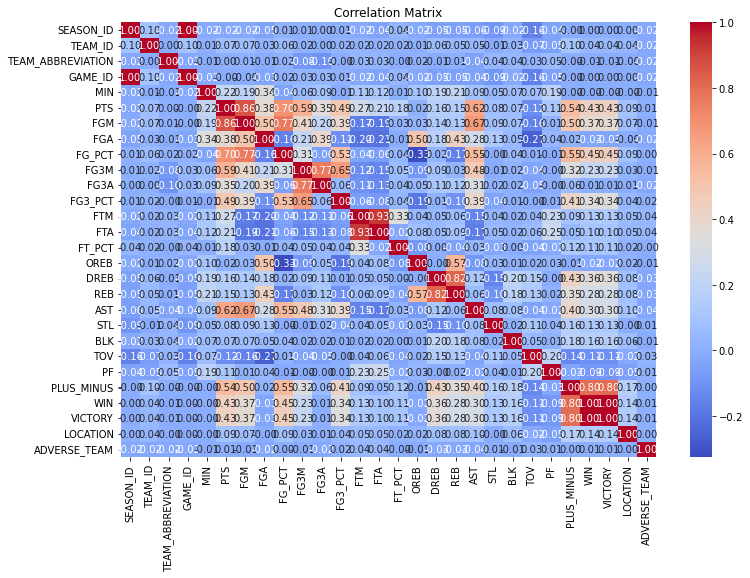

,GAME_ID,MATCHUP,LOCATION
0,22400359,TOR vs. NYK,1
1,22400359,NYK @ TOR,0
2,22400355,MIN @ GSW,0
3,22400350,ATL vs. DEN,1
4,22400358,LAL vs. POR,1


In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix = df_cleaned.corr()


# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()

# Vérification du résultat
df_cleaned[['GAME_ID', 'MATCHUP', 'LOCATION']].head()

Accuracy: 0.76
ROC AUC: 0.83


/Users/thibaultjames/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


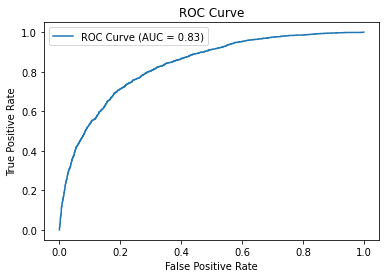

In [119]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Sélectionner les variables pertinentes
features = ['TEAM_ABBREVIATION','ADVERSE_TEAM','LOCATION','PTS','FG_PCT','FG3_PCT','DREB','AST']  # Ajouter d'autres stats ici si disponibles
X = df_cleaned[features]
y = df_cleaned['VICTORY']

# Diviser en jeu d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modèle de régression logistique
model = LogisticRegression()
model.fit(X_train, y_train)

# Prédictions et probabilités
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Probabilité d'une victoire

# Évaluation du modèle
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.2f}")
print(f"ROC AUC: {roc_auc:.2f}")

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [76]:
from sklearn.model_selection import GridSearchCV
params = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(LogisticRegression(), params, scoring='roc_auc', cv=5)
grid.fit(X_train, y_train)
print(f"Best C: {grid.best_params_['C']}")


/Users/thibaultjames/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/thibaultjames/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_

Best C: 10


/Users/thibaultjames/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [77]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"ROC AUC (mean ± std): {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

/Users/thibaultjames/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC AUC (mean ± std): 0.86 ± 0.00
